#**Caso de Estudio**
En este trabajo se realizará la integración de bases de datos correspondientes a diferentes centros de atención en salud del área metropolitana mediante la aplicación de métodos basados en el concepto de Aceptación y Rechazo. El objetivo es evaluar la compatibilidad estadística entre los datos de los distintos centros.

La variable utilizada para el análisis es el BMI (Índice de Masa Corporal) de los pacientes. Como base de datos observada se toma el centro de Sabaneta, mientras que las bases de datos de Bello, Medellín, Envigado, Itagüí y Caldas se consideran datos externos.

Para realizar la integración se lleva a cabo la caracterización estadística de las distribuciones mediante medidas de tendencia central y dispersión, como la media, desviación estándar, asimetría y curtosis. Posteriormente se aplican los métodos de Valor de Pertenencia y Aceptación–Rechazo para determinar el grado de similitud entre las distribuciones y establecer qué datos pueden integrarse con la base de datos de Sabaneta.


0. Se procede con la carga de las librerias de trabajo

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [116]:
def caracterizacion(LDA, nombre):

  # Gráfica de distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("BMI")
  plt.ylabel("Frecuencia")
  plt.title(f"Distribución de la variable BMI - {nombre}")
  plt.grid()
  plt.show()

  # Caracterización estadística
  np.set_printoptions(suppress=True)
  NI=10
  counts,bin_edges=np.histogram(LDA,bins=NI)

  print("Número de datos:", len(LDA))
  print("Número de datos por intervalo:")
  print(counts)

  XC=(bin_edges[:-1]+bin_edges[1:])/2

  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])

  # Cálculo de estadísticas
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  print("Media:", u)
  print("Desviación estándar:", sigma)
  print("Varianza:", sigma2)
  print("Coeficiente de asimetría:", Cas)
  print("Curtosis:", Kur)

  return u,sigma,Cas,Kur,df

1. Se procede con la carga de los archivos de trabajo

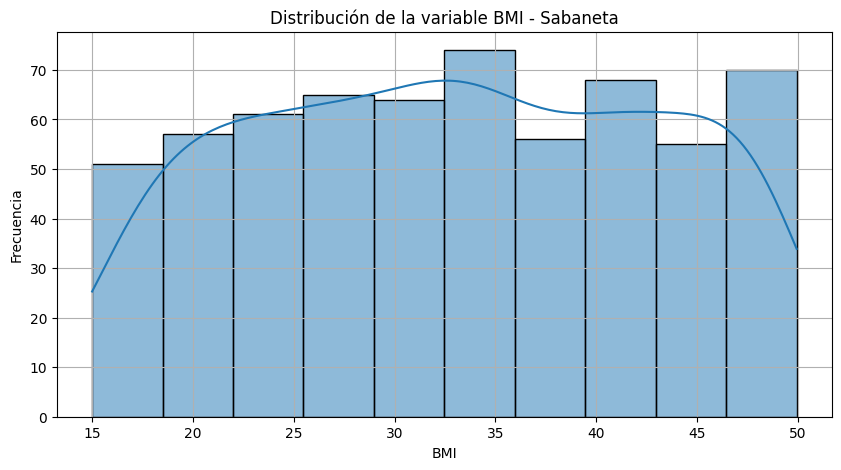

Número de datos: 621
Número de datos por intervalo:
[51 57 61 65 64 74 56 68 55 70]
Media: 32.96582487922706
Desviación estándar: 9.837867466860093
Varianza: 96.78363629550424
Coeficiente de asimetría: -0.025742157381107963
Curtosis: -1.1627829906265352


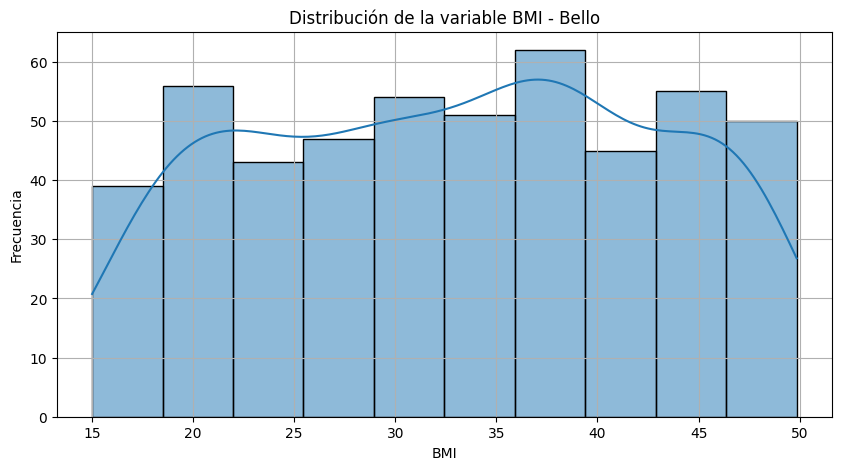

Número de datos: 502
Número de datos por intervalo:
[39 56 43 47 54 51 62 45 55 50]
Media: 32.9278406374502
Desviación estándar: 9.804369683459628
Varianza: 96.12566488994224
Coeficiente de asimetría: -0.0599453089846441
Curtosis: -1.1860520640673438


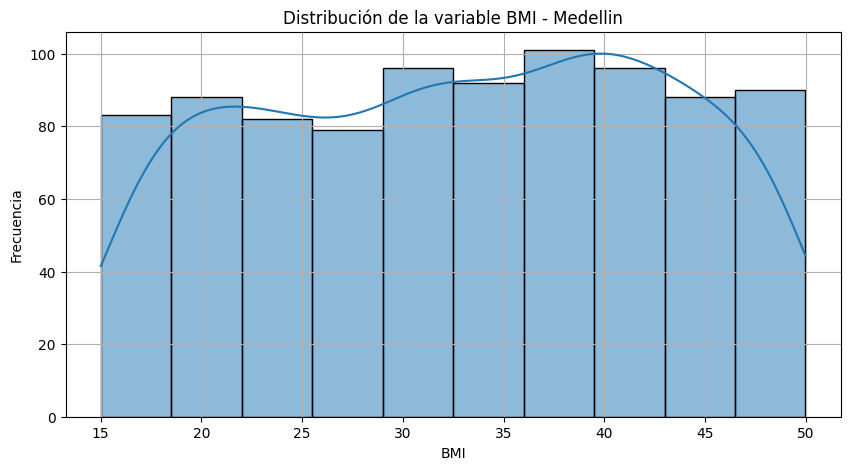

Número de datos: 895
Número de datos por intervalo:
[ 83  88  82  79  96  92 101  96  88  90]
Media: 32.870381843575416
Desviación estándar: 9.925651139843664
Varianza: 98.51855054987982
Coeficiente de asimetría: -0.06974264498227505
Curtosis: -1.1880147864485626


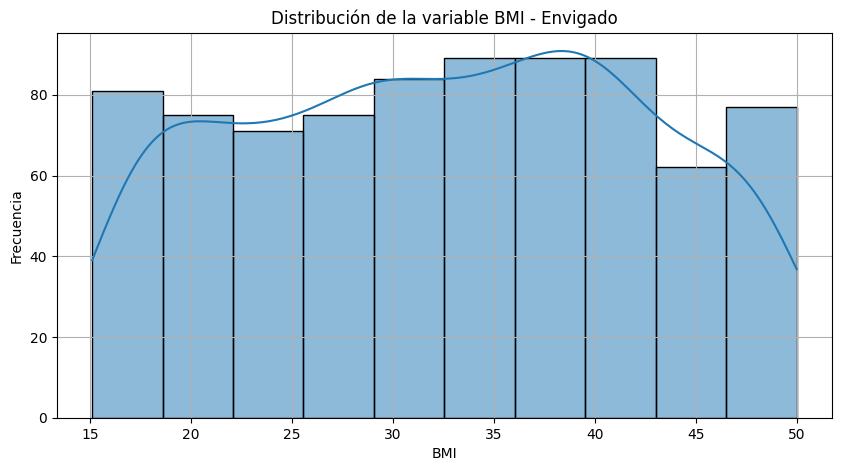

Número de datos: 792
Número de datos por intervalo:
[81 75 71 75 84 89 89 89 62 77]
Media: 32.56653093434344
Desviación estándar: 9.834442278208346
Varianza: 96.71625492341178
Coeficiente de asimetría: -0.040160184651065974
Curtosis: -1.1491841028973189


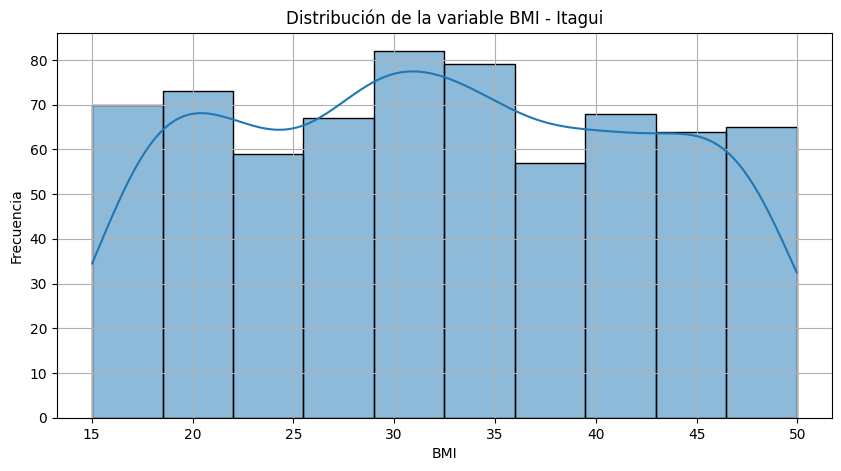

Número de datos: 684
Número de datos por intervalo:
[70 73 59 67 82 79 57 68 64 65]
Media: 32.2467649122807
Desviación estándar: 9.928945676671281
Varianza: 98.58396225028935
Coeficiente de asimetría: 0.027261582779057495
Curtosis: -1.172181742395808


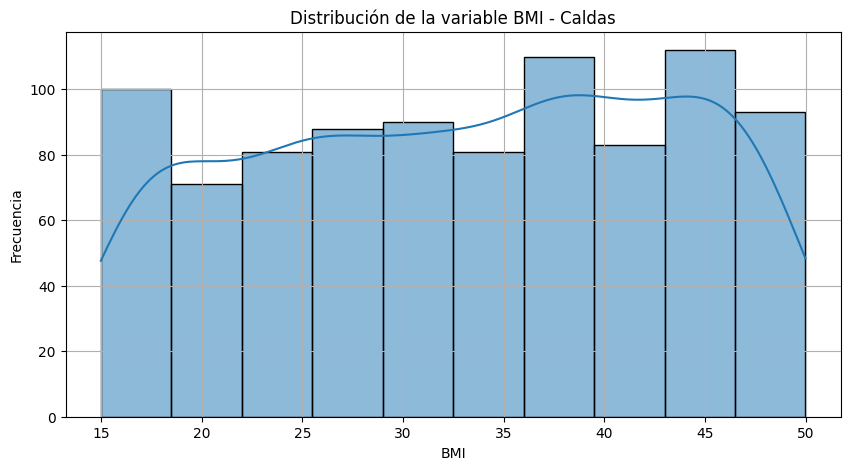

Número de datos: 909
Número de datos por intervalo:
[100  71  81  88  90  81 110  83 112  93]
Media: 33.05249092409241
Desviación estándar: 10.142511067582673
Varianza: 102.870530756037
Coeficiente de asimetría: -0.11052613512445673
Curtosis: -1.2181744314310725


In [117]:
nxlo='/content/drive/MyDrive/Integracion de datos y prospectiva/3. Parcial - medical_attention_data.xlsx'
#Sabaneta
XDB_sab = pd.read_excel(nxlo, sheet_name="Sabaneta")
LDA_sab = XDB_sab["BMI"]

us, sigmas, Cass, Kurs, dfs = caracterizacion(LDA_sab,"Sabaneta")
#Bello
XDB_bel = pd.read_excel(nxlo, sheet_name="Bello")
LDA_bel = XDB_bel["BMI"]

ub, sigmab, Casb, Kurb, dfb = caracterizacion(LDA_bel,"Bello")
#Medellin
XDB_med = pd.read_excel(nxlo, sheet_name="Medellin")
LDA_med = XDB_med["BMI"]

um, sigmam, Casm, Kurm, dfm = caracterizacion(LDA_med,"Medellin")
#Envigado
XDB_env = pd.read_excel(nxlo, sheet_name="Envigado")
LDA_env = XDB_env["BMI"]

ue, sigmae, Case, Kure, dfe = caracterizacion(LDA_env,"Envigado")
#Itagui
XDB_ita = pd.read_excel(nxlo, sheet_name="Itagui")
LDA_ita = XDB_ita["BMI"]

ui, sigmai, Casi, Kuri, dfi = caracterizacion(LDA_ita,"Itagui")
#Caldas
XDB_cal = pd.read_excel(nxlo, sheet_name="Caldas")
LDA_cal = XDB_cal["BMI"]

uc, sigmac, Casc, Kurc, dfc = caracterizacion(LDA_cal,"Caldas")

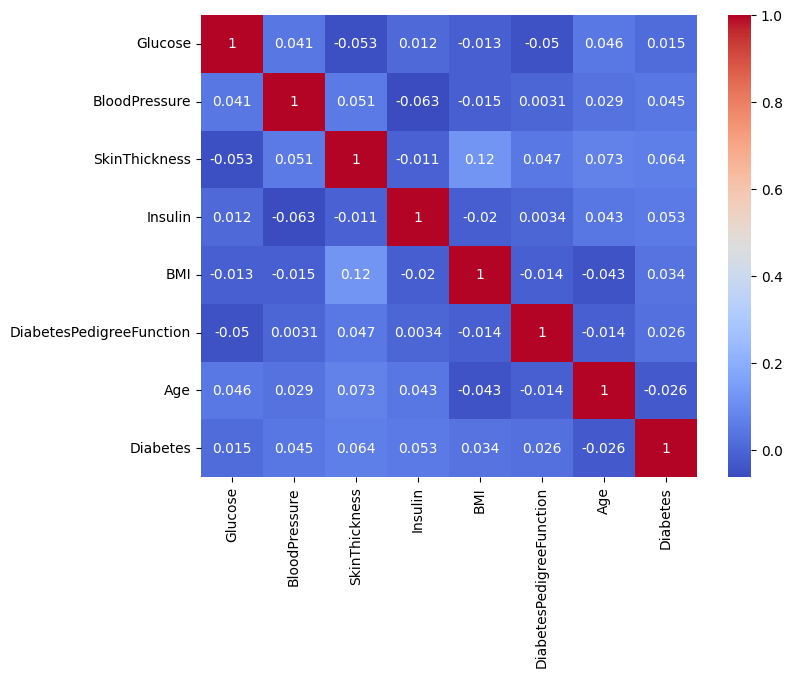

In [102]:
corr = XDB_sab.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


2. Se procede con la estimación de la teoría de la credibilidad

MÉTODO 1 - Valor de pertenencia
Datos integrados desde Bello : 140
Datos integrados desde Medellin : 237
Datos integrados desde Envigado : 221
Datos integrados desde Itagui : 196
Datos integrados desde Caldas : 226


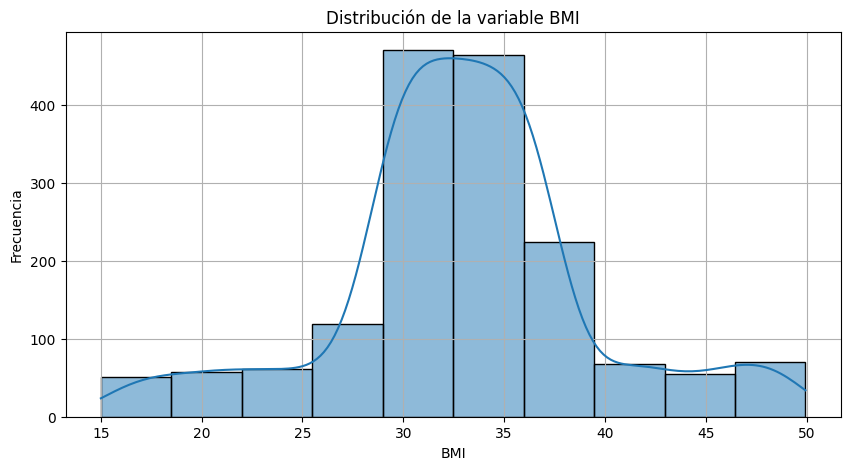

Número de datos: 1641
Número de datos por intervalo:
[ 51  57  61 119 471 465 224  68  55  70]
Media: 33.00687723948812
Desviación estándar: 6.452385673028181
Varianza: 41.63328087349934
Coeficiente de asimetría: -0.04450594694385948
Curtosis: 0.8125968429020465
Media de los datos integrados: 33.00687723948812
Media de Sabaneta: 32.96582487922706
Discrepancia porcentual: 0.12453005623690903


In [103]:
print("MÉTODO 1 - Valor de pertenencia")

LDAint1 = np.copy(np.array(LDA_sab))

centros = [LDA_bel, LDA_med, LDA_env, LDA_ita, LDA_cal]
nombres = ["Bello","Medellin","Envigado","Itagui","Caldas"]
contadores = []

for i in range(len(centros)):

    m = 0

    for x in centros[i]:

        VP = np.exp(-0.5*((us-x)/sigmas)**2)

        if VP > 0.9:
            m += 1
            LDAint1 = np.append(LDAint1,x)

    contadores.append(m)
    print("Datos integrados desde",nombres[i],":",m)


ui1,sigmai1,Casi1,Kuri1,dfi1 = caracterizacion(LDAint1)

print("Media de los datos integrados:",ui1)
print("Media de Sabaneta:",us)

duoui1 = np.abs((us-ui1)/us)*100
print("Discrepancia porcentual:",duoui1)

In [111]:
print("MÉTODO 2 - Aceptacion y Rechazo")
# contadores de integración
bel=0
med=0
env=0
ita=0
cal=0

sigma_sab = np.std(LDA_sab)

for k in range(len(LDA_sab)):

    x=LDA_sab[k]

    # probabilidad en Sabaneta (distribución base)
    VPg=np.exp(-0.5*((us-x)/sigma_sab)**2)

    # probabilidades en cada sucursal
    VP_bel=np.exp(-0.5*((ub-x)/sigmab)**2)
    VP_med=np.exp(-0.5*((um-x)/sigmam)**2)
    VP_env=np.exp(-0.5*((ue-x)/sigmae)**2)
    VP_ita=np.exp(-0.5*((ui-x)/sigmai)**2)
    VP_cal=np.exp(-0.5*((uc-x)/sigmac)**2)

    # números aleatorios
    a1=np.random.random()
    a2=np.random.random()
    a3=np.random.random()
    a4=np.random.random()
    a5=np.random.random()

    # aceptación-rechazo
    if (VP_bel/VPg)>a1:
        bel+=1

    if (VP_med/VPg)>a2:
        med+=1

    if (VP_env/VPg)>a3:
        env+=1

    if (VP_ita/VPg)>a4:
        ita+=1

    if (VP_cal/VPg)>a5:
        cal+=1

print("Datos que se integrarían desde Sabaneta:")
print("Bello:",bel)
print("Medellin:",med)
print("Envigado:",env)
print("Itagui:",ita)
print("Caldas:",cal)

MÉTODO 2 - Aceptacion y Rechazo
Datos que se integrarían desde Sabaneta:
Bello: 613
Medellin: 620
Envigado: 608
Itagui: 602
Caldas: 621


In [105]:
VP_bello = np.exp(-0.5*((us-ub)/sigmas)**2)
VP_medellin = np.exp(-0.5*((us-um)/sigmas)**2)
VP_envigado = np.exp(-0.5*((us-ue)/sigmas)**2)
VP_itagui = np.exp(-0.5*((us-ui)/sigmas)**2)
VP_caldas = np.exp(-0.5*((us-uc)/sigmas)**2)

print("Afinidad con Bello:",VP_bello)
print("Afinidad con Medellin:",VP_medellin)
print("Afinidad con Envigado:",VP_envigado)
print("Afinidad con Itagui:",VP_itagui)
print("Afinidad con Caldas:",VP_caldas)

Afinidad con Bello: 0.9999925462748588
Afinidad con Medellin: 0.9999529406051447
Afinidad con Envigado: 0.9991766686119612
Afinidad con Itagui: 0.9973324142649825
Afinidad con Caldas: 0.9999611976884885


In [106]:
# Numero de datos de Sabaneta
NDo=len(LDA_sab)

# Sabaneta vs Bello
NDb=len(LDA_bel)

EPV=(sigmas*NDo+sigmab*NDb)/(NDo+NDb)
uh=(us*NDo+ub*NDb)/(NDo+NDb)
VHM=((NDo*us**2+NDb*ub**2)/(NDo+NDb))-uh**2
fc=EPV/VHM

Cr_bello=NDo/(NDo+fc)
print("Credibilidad Sabaneta vs Bello:",Cr_bello)


# Sabaneta vs Medellin
NDm=len(LDA_med)

EPV=(sigmas*NDo+sigmam*NDm)/(NDo+NDm)
uh=(us*NDo+um*NDm)/(NDo+NDm)
VHM=((NDo*us**2+NDm*um**2)/(NDo+NDm))-uh**2
fc=EPV/VHM

Cr_medellin=NDo/(NDo+fc)
print("Credibilidad Sabaneta vs Medellin:",Cr_medellin)


# Sabaneta vs Envigado
NDe=len(LDA_env)

EPV=(sigmas*NDo+sigmae*NDe)/(NDo+NDe)
uh=(us*NDo+ue*NDe)/(NDo+NDe)
VHM=((NDo*us**2+NDe*ue**2)/(NDo+NDe))-uh**2
fc=EPV/VHM

Cr_envigado=NDo/(NDo+fc)
print("Credibilidad Sabaneta vs Envigado:",Cr_envigado)


# Sabaneta vs Itagui
NDi=len(LDA_ita)

EPV=(sigmas*NDo+sigmai*NDi)/(NDo+NDi)
uh=(us*NDo+ui*NDi)/(NDo+NDi)
VHM=((NDo*us**2+NDi*ui**2)/(NDo+NDi))-uh**2
fc=EPV/VHM

Cr_itagui=NDo/(NDo+fc)
print("Credibilidad Sabaneta vs Itagui:",Cr_itagui)


# Sabaneta vs Caldas
NDc=len(LDA_cal)

EPV=(sigmas*NDo+sigmac*NDc)/(NDo+NDc)
uh=(us*NDo+uc*NDc)/(NDo+NDc)
VHM=((NDo*us**2+NDc*uc**2)/(NDo+NDc))-uh**2
fc=EPV/VHM

Cr_caldas=NDo/(NDo+fc)
print("Credibilidad Sabaneta vs Caldas:",Cr_caldas)

Credibilidad Sabaneta vs Bello: 0.022050146729361828
Credibilidad Sabaneta vs Medellin: 0.1215194250498064
Credibilidad Sabaneta vs Envigado: 0.7126161490227079
Credibilidad Sabaneta vs Itagui: 0.8901234540257725
Credibilidad Sabaneta vs Caldas: 0.10093355882909404


3. ¿Cuáles son los datos de integración?

In [107]:
# Bases de integración
LDAint_bel=np.copy(np.array(LDA_bel))
LDAint_med=np.copy(np.array(LDA_med))
LDAint_env=np.copy(np.array(LDA_env))
LDAint_ita=np.copy(np.array(LDA_ita))
LDAint_cal=np.copy(np.array(LDA_cal))

LDA_sab=np.array(LDA_sab)

m_bel=0
m_med=0
m_env=0
m_ita=0
m_cal=0

for k in range(len(LDA_sab)):

    x=LDA_sab[k]

    VP_bel=np.exp(-0.5*((ub-x)/sigmab)**2)
    VP_med=np.exp(-0.5*((um-x)/sigmam)**2)
    VP_env=np.exp(-0.5*((ue-x)/sigmae)**2)
    VP_ita=np.exp(-0.5*((ui-x)/sigmai)**2)
    VP_cal=np.exp(-0.5*((uc-x)/sigmac)**2)

    VP_max=max(VP_bel,VP_med,VP_env,VP_ita,VP_cal)

    if VP_max>0.9:

        if VP_max==VP_bel:
            LDAint_bel=np.append(LDAint_bel,x)
            m_bel+=1
            print("Paciente",x,"integrado a Bello")

        elif VP_max==VP_med:
            LDAint_med=np.append(LDAint_med,x)
            m_med+=1
            print("Paciente",x,"integrado a Medellin")

        elif VP_max==VP_env:
            LDAint_env=np.append(LDAint_env,x)
            m_env+=1
            print("Paciente",x,"integrado a Envigado")

        elif VP_max==VP_ita:
            LDAint_ita=np.append(LDAint_ita,x)
            m_ita+=1
            print("Paciente",x,"integrado a Itagui")

        elif VP_max==VP_cal:
            LDAint_cal=np.append(LDAint_cal,x)
            m_cal+=1
            print("Paciente",x,"integrado a Caldas")

Paciente 31.01 integrado a Itagui
Paciente 27.789 integrado a Itagui
Paciente 33.292 integrado a Caldas
Paciente 30.47 integrado a Itagui
Paciente 34.06 integrado a Caldas
Paciente 29.303 integrado a Itagui
Paciente 33.724 integrado a Caldas
Paciente 37.413 integrado a Caldas
Paciente 37.373 integrado a Caldas
Paciente 35.347 integrado a Caldas
Paciente 37.416 integrado a Caldas
Paciente 35.372 integrado a Caldas
Paciente 34.679 integrado a Caldas
Paciente 28.697 integrado a Itagui
Paciente 35.762 integrado a Caldas
Paciente 28.14 integrado a Itagui
Paciente 34.013 integrado a Caldas
Paciente 27.871 integrado a Itagui
Paciente 35.612 integrado a Caldas
Paciente 30.83 integrado a Itagui
Paciente 30.261 integrado a Itagui
Paciente 31.919 integrado a Itagui
Paciente 37.023 integrado a Caldas
Paciente 35.592 integrado a Caldas
Paciente 32.126 integrado a Itagui
Paciente 30.146 integrado a Itagui
Paciente 29.99 integrado a Itagui
Paciente 36.297 integrado a Caldas
Paciente 28.899 integrado 

In [112]:
print("MÉTODO 3- Teoria de la credibilidad")
print("Integrados en Bello:",m_bel)
print("Integrados en Medellin:",m_med)
print("Integrados en Envigado:",m_env)
print("Integrados en Itagui:",m_ita)
print("Integrados en Caldas:",m_cal)

MÉTODO 3- Teoria de la credibilidad
Integrados en Bello: 1
Integrados en Medellin: 2
Integrados en Envigado: 11
Integrados en Itagui: 87
Integrados en Caldas: 91


Caracterización Bello después de integrar


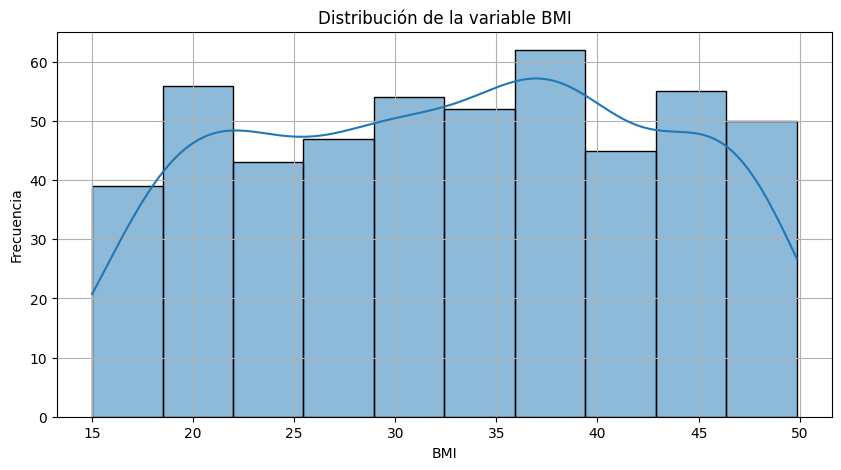

Número de datos: 503
Número de datos por intervalo:
[39 56 43 47 54 52 62 45 55 50]
Media: 32.930311133200796
Desviación estándar: 9.79477534554505
Varianza: 95.93762406969715
Coeficiente de asimetría: -0.060754729120117465
Curtosis: -1.1824932830321078
Caracterización Medellin después de integrar


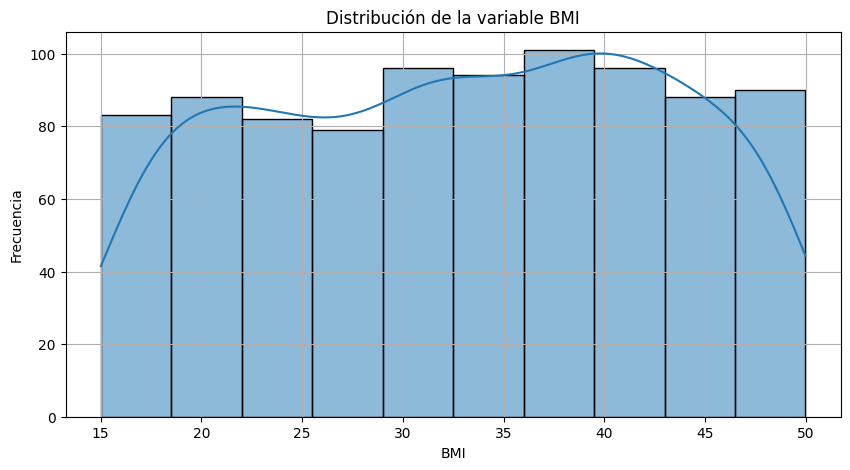

Número de datos: 897
Número de datos por intervalo:
[ 83  88  82  79  96  94 101  96  88  90]
Media: 32.873430379041245
Desviación estándar: 9.914789312018227
Varianza: 98.30304710171086
Coeficiente de asimetría: -0.0707326689547538
Curtosis: -1.1840320820620118
Caracterización Envigado después de integrar


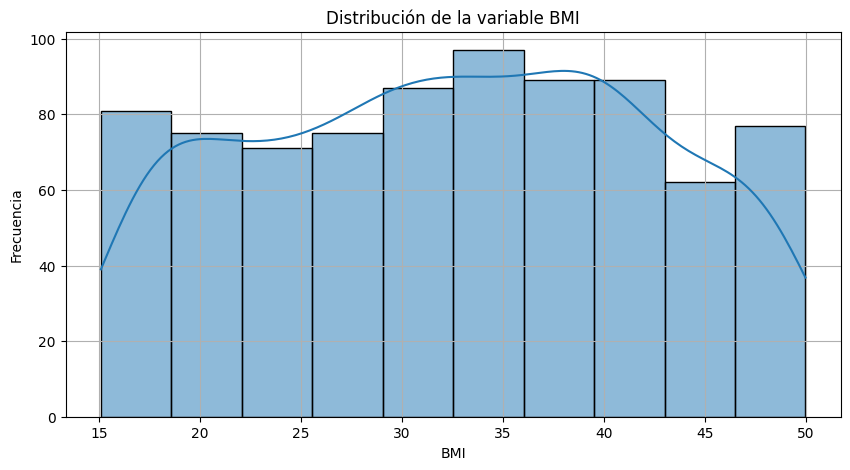

Número de datos: 803
Número de datos por intervalo:
[81 75 71 75 87 97 89 89 62 77]
Media: 32.577093711083435
Desviación estándar: 9.76895575701723
Varianza: 95.43249658256008
Coeficiente de asimetría: -0.04362321848752673
Curtosis: -1.124899872217081
Caracterización Itagui después de integrar


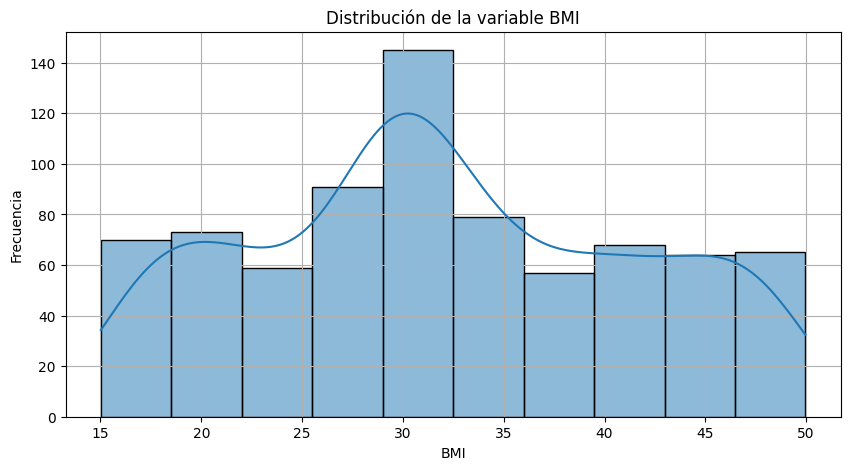

Número de datos: 771
Número de datos por intervalo:
[ 70  73  59  91 145  79  57  68  64  65]
Media: 31.96848988326849
Desviación estándar: 9.399138040445397
Varianza: 88.34379590334774
Coeficiente de asimetría: 0.11234520499712343
Curtosis: -0.9701424414513067
Caracterización Caldas después de integrar


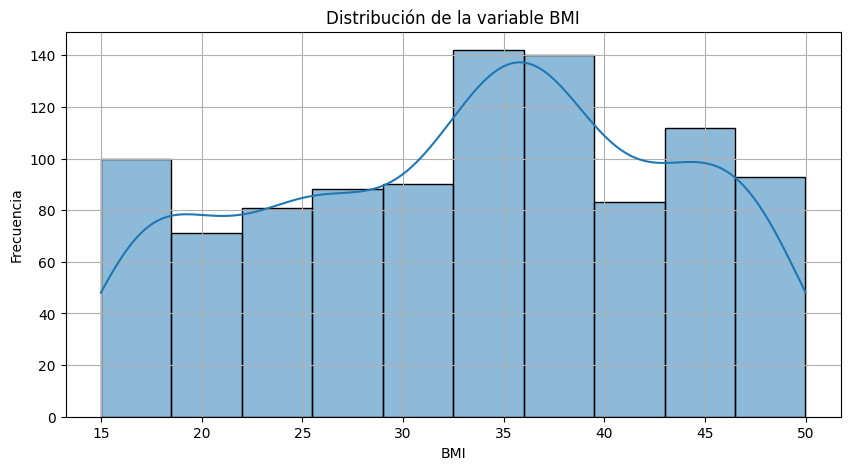

Número de datos: 1000
Número de datos por intervalo:
[100  71  81  88  90 142 140  83 112  93]
Media: 33.265668500000004
Desviación estándar: 9.706152425091405
Varianza: 94.20939489910775
Coeficiente de asimetría: -0.17704491377548456
Curtosis: -1.0545153151924058


(np.float64(33.265668500000004),
 np.float64(9.706152425091405),
 np.float64(-0.17704491377548456),
 np.float64(-1.0545153151924058),
         LI       LS        XC     ND
 0  15.0000  18.4985  16.74925  100.0
 1  18.4985  21.9970  20.24775   71.0
 2  21.9970  25.4955  23.74625   81.0
 3  25.4955  28.9940  27.24475   88.0
 4  28.9940  32.4925  30.74325   90.0
 5  32.4925  35.9910  34.24175  142.0
 6  35.9910  39.4895  37.74025  140.0
 7  39.4895  42.9880  41.23875   83.0
 8  42.9880  46.4865  44.73725  112.0
 9  46.4865  49.9850  48.23575   93.0)

In [109]:
print("Caracterización Bello después de integrar")
caracterizacion(LDAint_bel)

print("Caracterización Medellin después de integrar")
caracterizacion(LDAint_med)

print("Caracterización Envigado después de integrar")
caracterizacion(LDAint_env)

print("Caracterización Itagui después de integrar")
caracterizacion(LDAint_ita)

print("Caracterización Caldas después de integrar")
caracterizacion(LDAint_cal)

**Análisis de los Datos**
### Conclusión General

A partir de la aplicación de los tres métodos de integración de datos —**Valor de Pertenencia, Aceptación y Rechazo, y Teoría de la Credibilidad**— fue posible evaluar el grado de compatibilidad entre las distribuciones de BMI de las diferentes sucursales respecto a la base de datos de **Sabaneta**, utilizada como referencia en el análisis.

Mediante el **método de Valor de Pertenencia** se observó que las sucursales con mayor cantidad de datos integrados son **Medellín (237)** y **Caldas (226)**, seguidas por **Envigado (221)**, **Itagüí (196)** y **Bello (140)**. Estos resultados indican que Medellín y Caldas presentan una mayor similitud estadística con la distribución de BMI de Sabaneta, lo que sugiere que una mayor proporción de sus datos puede integrarse sin alterar significativamente la estructura de la distribución base.

Por otro lado, el **método de Aceptación y Rechazo** mostró valores relativamente altos y similares entre las sucursales, con **Caldas (621)** y **Medellín (620)** como los centros con mayor número de datos aceptados, seguidos por **Bello (613)**, **Envigado (608)** e **Itagüí (602)**. Esto indica que, desde una perspectiva probabilística, las distribuciones de BMI de las distintas sucursales presentan un comportamiento bastante cercano al de la base de referencia. Sin embargo, el hecho de que todos los centros presenten valores cercanos a los **600 registros aceptados** sugiere que este método tiende a aceptar una proporción elevada de datos, lo que lo hace menos restrictivo para diferenciar entre las bases analizadas.

Finalmente, la **Teoría de la Credibilidad** permitió evaluar la confiabilidad estadística de cada base de datos dentro del proceso de integración. En este caso, las sucursales con mayor número de datos integrados fueron **Caldas (91)** e **Itagüí (87)**, mientras que **Envigado (11)**, **Medellín (2)** y **Bello (1)** presentaron valores considerablemente menores. Este resultado indica que, aunque algunos centros pueden presentar similitudes probabilísticas con la base de referencia, no todos aportan el mismo nivel de confiabilidad estadística dentro del proceso de integración.

En conjunto, los resultados muestran que **Caldas** aparece de manera consistente entre las sucursales con mayor integración en los tres métodos, mientras que **Medellín** también presenta una alta compatibilidad en los métodos de Valor de Pertenencia y Aceptación–Rechazo. No obstante, la **Teoría de la Credibilidad** resulta especialmente importante en el análisis, ya que permite distinguir qué fuentes de información realmente aportan mayor consistencia estadística. De esta manera, aunque los métodos de aceptación permiten integrar una gran cantidad de datos, el análisis de credibilidad contribuye a **priorizar aquellas bases de datos que fortalecen la calidad y robustez del conjunto de datos integrado**, permitiendo realizar análisis posteriores de manera más confiable.
